# Pipeline de calidad de datos — paso a paso

Este notebook **desenrolla `ingest.run_pipeline()`** para que veas qué hace cada etapa y cuántas filas toca.
Solo cubre calidad de datos (F1): no hay forecast ni política de rebalanceo.

**Idea central.** La identidad contable

$$\text{balance}_t = \text{balance}_{t-1} + \text{inflow}_t - \text{outflow}_t$$

es la *llave de respuesta* de los datos: elige el duplicado correcto, reconstruye nulos, detecta lecturas corruptas.
Lo que la identidad no puede resolver se pone en cuarentena, se marca y se reporta. **Nada se descarta en silencio.**

| # | Problema | Sección |
|---|---|---|
| P1 | Fechas en 3 formatos | 2 |
| P2 | Etiquetas de moneda inconsistentes | 3 |
| **P3** | **Pares (fecha, cuenta) duplicados con balance distinto** | **4 (detalle completo)** |
| P4 | Nulos en balance / inflow / outflow | 5 |
| P5 | Lecturas corruptas (signo invertido, decimal corrido) | 6 |
| P6 | Episodios sin explicación → cuarentena | 7 |
| P7 | Identidad contable del panel final | 8 |
| — | Transferencias duplicadas | 9 |

In [1]:
import sys
from pathlib import Path

# el notebook vive en notebooks/: se sube hasta encontrar la carpeta src/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from src import config as cfg, ingest, quality

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

---
## 1 · Carga y contrato de datos

El crudo se lee con la **fecha como texto** (el formato es mixto). El contrato esperado vive en `config.py`.

In [2]:
accounts = ingest.load_accounts()
raw = ingest.load_raw_balances()

print(f"filas crudas: {len(raw)}  (contrato: {cfg.EXPECTED_RAW_ROWS})")
print(f"panel esperado: {cfg.EXPECTED_ACCOUNTS} cuentas × {cfg.EXPECTED_DAYS} días = {cfg.EXPECTED_PANEL_ROWS}")
print(f"→ el crudo trae {len(raw) - cfg.EXPECTED_PANEL_ROWS} filas más que el panel (pista para P3)")
accounts

filas crudas: 1668  (contrato: 1668)
panel esperado: 6 cuentas × 270 días = 1620
→ el crudo trae 48 filas más que el panel (pista para P3)


,account_id,bank_name,currency,account_type
0,ACC-001,Banco Aurora,COP,operational
1,ACC-002,Banco Aurora,USD,operational
2,ACC-003,Banco Sureste,COP,reserve
3,ACC-004,Banco Azteca+,MXN,operational
4,ACC-005,Banco Azteca+,MXN,reserve
5,ACC-006,Banco Norte,USD,reserve


In [3]:
raw.head(8)

,date,account_id,currency,balance,inflow,outflow
0,2025-08-14,ACC-003,COP,"2,987,754,672.78","106,176,633.39","104,803,833.71"
1,2025-05-06,ACC-006,USD,"148,343.19","1,906.44","6,631.36"
2,2025-08-30,ACC-001,COP,"2,422,127,448.26","35,064,305.57","67,044,824.40"
3,22/05/2025,ACC-001,COP,"2,596,890,597.82","136,774,255.65","111,506,890.94"
4,2025-07-03,ACC-005,Mexican Peso,"136,815,700.26","4,004,621.54","3,866,024.29"
5,09-18-2025,ACC-002,USD,"79,622.92","2,219.77","5,035.43"
6,2025-01-12,ACC-002,USD,"173,106.62","2,225.36",0.00
7,04-09-2025,ACC-005,MXN,"162,803,746.66","5,147,697.81","5,758,720.55"


---
## 2 · P1 — Fechas en 3 formatos

El separador desambigua el formato: `-` con año primero = ISO, `/` = DD/MM/YYYY, `-` con año al final = MM-DD-YYYY.
El parser del squad (`to_datetime(errors='coerce')` + `dropna`) **pierde en silencio** los que no son ISO.

In [4]:
fmt_counts = quality.date_format_counts(raw)
lost, total = quality.naive_parse_loss(raw)
print(fmt_counts.to_string())
print(f"\nparser del squad pierde {lost} de {total} filas ({lost/total:.1%})")
assert lost == fmt_counts.drop("%Y-%m-%d").sum()   # justo los formatos no-ISO

date
%Y-%m-%d    1375
%d/%m/%Y     170
%m-%d-%Y     123

parser del squad pierde 293 de 1668 filas (17.6%)


In [5]:
# ejemplos de cada formato
raw.assign(formato=raw["date"].map(lambda v: ingest.date_format_of(v)))\
   .groupby("formato")["date"].apply(lambda s: s.head(3).tolist())

formato
%Y-%m-%d    [2025-08-14, 2025-05-06, 2025-08-30]
%d/%m/%Y    [22/05/2025, 25/08/2025, 10/06/2025]
%m-%d-%Y    [09-18-2025, 04-09-2025, 06-19-2025]
Name: date, dtype: object

In [6]:
# parser en cascada: falla ruidosamente si algo no encaja, nunca produce NaT
raw["date_parsed"] = ingest.parse_mixed_dates(raw["date"])
print("NaT tras el parseo:", int(raw["date_parsed"].isna().sum()))
print("rango:", raw["date_parsed"].min().date(), "→", raw["date_parsed"].max().date())

NaT tras el parseo: 0
rango: 2025-01-01 → 2025-09-27


---
## 3 · P2 — Etiquetas de moneda

`accounts.csv` es la fuente de verdad: cada cuenta tiene **una** moneda. En el crudo hay 9 etiquetas para 3 monedas.

In [7]:
print(raw["currency"].value_counts().to_string())
canonical = {"COP", "USD", "MXN"}
print(f"\netiquetas distintas: {raw['currency'].nunique()} (deben ser 3)")
print(f"filas con etiqueta no canónica: {(~raw['currency'].isin(canonical)).sum()}")

currency
USD               503
COP               496
MXN               482
mxn                37
Mexican Peso       35
usd                33
cop                30
Colombian Peso     30
US Dollar          22

etiquetas distintas: 9 (deben ser 3)
filas con etiqueta no canónica: 187


In [8]:
# normaliza a ISO-4217 y valida contra accounts.csv; falla si alguna etiqueta no está mapeada o contradice la cuenta
raw["currency_norm"] = ingest.normalize_currency(raw["currency"], raw["account_id"], accounts)
pd.crosstab(raw["currency"], raw["currency_norm"])

currency_norm,COP,MXN,USD
currency,,,
COP,496,0,0
Colombian Peso,30,0,0
MXN,0,482,0
Mexican Peso,0,35,0
US Dollar,0,0,22
USD,0,0,503
cop,30,0,0
mxn,0,37,0
usd,0,0,33


---
## 4 · P3 — Pares (fecha, cuenta) duplicados con balance distinto

Esta es la sección de detalle. El objetivo: **cómo se encuentran, cómo se clasifican y cómo se elige la fila correcta.**

### 4.1 · Pista aritmética: sobran 48 filas

In [9]:
sizes = raw.groupby(["account_id", "date_parsed"]).size()

print(f"filas crudas                  : {len(raw)}")
print(f"pares (cuenta, fecha) únicos  : {len(sizes)}   (= {cfg.EXPECTED_ACCOUNTS} × {cfg.EXPECTED_DAYS}: cada día-cuenta aparece al menos una vez)")
print(f"filas sobrantes               : {len(raw) - len(sizes)}")
sizes.value_counts().rename("pares").rename_axis("filas por (cuenta, fecha)").to_frame()

filas crudas                  : 1668
pares (cuenta, fecha) únicos  : 1620   (= 6 × 270: cada día-cuenta aparece al menos una vez)
filas sobrantes               : 48


,pares
"filas por (cuenta, fecha)",
1,1572
2,48


1.668 filas para 1.620 días-cuenta ⇒ hay 48 días-cuenta con **dos** filas. Ningún día tiene más de dos ni ninguno queda sin fila.

### 4.2 · Detectarlos: agrupar por (cuenta, fecha *ya parseada*)

Se agrupa por la fecha **parseada** (sección 2): si se agrupara por el texto, un día escrito como `12/02/2025` y otro como `2025-02-12` no se reconocerían como el mismo.
En este dataset las dos filas de cada par vienen con el mismo texto, pero el pipeline no puede asumirlo.

In [10]:
dup_rows = raw[raw.duplicated(["account_id", "date_parsed"], keep=False)].sort_values(["account_id", "date_parsed"])
pairs = dup_rows.groupby(["account_id", "date_parsed"])

print(f"pares detectados: {pairs.ngroups}  ({len(dup_rows)} filas)")
print("pares cuyo texto de fecha difiere entre las 2 filas:", int((pairs["date"].nunique() > 1).sum()))
print("pares cuyo texto de moneda difiere               :", int((pairs["currency"].nunique() > 1).sum()))

# ¿un drop_duplicates() normal los habría detectado?
orig_cols = ["date", "account_id", "currency", "balance", "inflow", "outflow"]
print("\nfilas que atrapa raw.drop_duplicates():", int(raw.duplicated(orig_cols).sum()), "de 48")

pares detectados: 48  (96 filas)
pares cuyo texto de fecha difiere entre las 2 filas: 0
pares cuyo texto de moneda difiere               : 0

filas que atrapa raw.drop_duplicates(): 4 de 48


Un `drop_duplicates()` común solo atrapa **4** pares. Los otros 44 no son copias exactas: el balance cambia, y por eso nadie los ve con una revisión superficial. Además, el notebook del squad no trata duplicados en ningún paso (solo `to_datetime` + `dropna`), así que esos 48 días entran dos veces a sus ventanas móviles.

### 4.3 · Clasificarlos: ¿qué columnas difieren dentro de cada par?

In [11]:
summary = pairs.agg(
    n_balances=("balance", "count"),                                          # balances no nulos en el par
    n_balances_distintos=("balance", "nunique"),
    inflow_distintos=("inflow", lambda s: s.nunique(dropna=False)),           # NaN cuenta como un valor
    outflow_distintos=("outflow", lambda s: s.nunique(dropna=False)),
)
summary["tipo"] = np.select(
    [summary["n_balances_distintos"] == 2, summary["n_balances"] == 0],
    ["balance distinto", "ambos nulos"],
    default="otro",
)

print(summary["tipo"].value_counts().to_string())
print("\ninflow  idéntico en las 2 filas de TODOS los pares:", bool((summary["inflow_distintos"] == 1).all()))
print("outflow idéntico en las 2 filas de TODOS los pares:", bool((summary["outflow_distintos"] == 1).all()))

tipo
balance distinto    44
ambos nulos          4

inflow  idéntico en las 2 filas de TODOS los pares: True
outflow idéntico en las 2 filas de TODOS los pares: True


- **44 pares**: mismo inflow, mismo outflow, **distinto balance** → este es "P3 pares duplicados con balance distinto".
- **4 pares**: el balance es nulo en las dos filas → son copias exactas, no hay balance que comparar.

Como inflow/outflow son iguales, la única pregunta es cuál de los dos balances es el real.

### 4.4 · ¿Qué tan distintos son los dos balances?

In [12]:
conf = summary[summary["tipo"] == "balance distinto"].index
gap = pairs["balance"].agg(lambda s: (s.max() - s.min()) / s.mean()).loc[conf]
(gap * 100).describe().rename("diferencia relativa entre los 2 balances (%)").map("{:.4f}%".format).to_frame()

,diferencia relativa entre los 2 balances (%)
count,44.0000%
mean,0.0442%
std,0.0244%
min,0.0012%
25%,0.0298%
50%,0.0435%
75%,0.0556%
max,0.0974%


La diferencia está entre ~0,001% y ~0,1%: es demasiado pequeña para verse como un outlier. Una regla como "descarta valores extremos" no sirve; hace falta un criterio contable.

### 4.5 · Elegir con la identidad: un ejemplo trabajado

Para cada candidato `c` del día *t* se calcula el residuo contra lo que dice la contabilidad:

- **hacia adelante**: `|c − (balance[t−1] + inflow[t] − outflow[t])|`
- **hacia atrás**: `|balance[t+1] − (c + inflow[t+1] − outflow[t+1])|`

El candidato verdadero deja residuo ≈ 0 (≤ `RECONCILIATION_TOL`); el otro queda muy por encima.

In [13]:
ledger = ingest.reconcile_ledger(raw)          # 1 registro por (cuenta, día); guarda cand_1 / cand_2
led = ledger.set_index(["account_id", "date"])
TOL = cfg.RECONCILIATION_TOL


def neighbour_balances(acc, day, source):
    """Balances del vecino: 'clean' = ya resuelto en el ledger; 'raw' = lo que reporta el crudo."""
    if (acc, day) not in led.index:
        return []
    r = led.loc[(acc, day)]
    return [r["balance_clean"]] if source == "clean" else [v for v in (r["cand_1"], r["cand_2"]) if pd.notna(v)]


def residual(c, acc, day, source="clean"):
    """Menor residuo de la identidad para el candidato c, mirando el día anterior y el siguiente."""
    one_day = pd.Timedelta(days=1)
    r_t = led.loc[(acc, day)]
    out = []
    infl, outf = r_t["inflow_raw"], r_t["outflow_raw"]
    if pd.notna(infl) and pd.notna(outf):                                    # hacia adelante
        out += [abs(c - (p + infl - outf)) for p in neighbour_balances(acc, day - one_day, source)]
    if (acc, day + one_day) in led.index:                                    # hacia atrás
        n_in, n_out = led.loc[(acc, day + one_day)][["inflow_raw", "outflow_raw"]]
        if pd.notna(n_in) and pd.notna(n_out):
            out += [abs(n - (c + n_in - n_out)) for n in neighbour_balances(acc, day + one_day, source)]
    return min(out) if out else np.nan


# ejemplo: primer par con balance distinto
acc, day = conf[0]
print(f"{acc} · {day.date()}")
print("\nfilas crudas del par:")
display(dup_rows[(dup_rows["account_id"] == acc) & (dup_rows["date_parsed"] == day)][["date", "account_id", "balance", "inflow", "outflow"]])

r = led.loc[(acc, day)]
prev = led.loc[(acc, day - pd.Timedelta(days=1))]
print(f"balance[t-1] (resuelto)          : {prev['balance_clean']:>20,.2f}")
print(f"+ inflow[t] - outflow[t]         : {r['inflow_raw'] - r['outflow_raw']:>20,.2f}")
print(f"= balance esperado en t          : {prev['balance_clean'] + r['inflow_raw'] - r['outflow_raw']:>20,.2f}\n")
for k, c in enumerate((r["cand_1"], r["cand_2"]), 1):
    res = residual(c, acc, day)
    print(f"candidato {k}: {c:>20,.2f}   residuo = {res:>14,.2f}   → {'CUADRA' if res <= TOL else 'descartado'}")

ACC-001 · 2025-02-12

filas crudas del par:


,date,account_id,balance,inflow,outflow
661,2025-02-12,ACC-001,"2,369,696,014.90","257,832.12","109,505,637.81"
1271,2025-02-12,ACC-001,"2,369,590,098.91","257,832.12","109,505,637.81"


balance[t-1] (resuelto)          :     2,478,943,820.59
+ inflow[t] - outflow[t]         :      -109,247,805.69
= balance esperado en t          :     2,369,696,014.90

candidato 1:     2,369,696,014.90   residuo =           0.00   → CUADRA
candidato 2:     2,369,590,098.91   residuo =     105,915.99   → descartado


#### Ejemplos con desglose completo: cómo se descarta el duplicado

`explain_pair(cuenta, fecha)` muestra las dos filas crudas, el balance que *debería* tener ese día según la contabilidad, y el residuo de cada candidato contra el día anterior y el siguiente. Sirve para cualquier par de la tabla 4.6.

In [14]:
def explain_pair(acc, day):
    """Desglose de cómo la identidad contable descarta uno de los dos balances de un par duplicado."""
    day, one = pd.Timestamp(day), pd.Timedelta(days=1)
    r, prev, nxt = led.loc[(acc, day)], led.loc[(acc, day - one)], led.loc[(acc, day + one)]
    expected = prev["balance_clean"] + r["inflow_raw"] - r["outflow_raw"]

    print(f"===== {acc} · {day.date()} =====\n")
    print("filas crudas del par:")
    display(raw[(raw["account_id"] == acc) & (raw["date_parsed"] == day)][["date", "balance", "inflow", "outflow"]])

    print(f"balance de ayer (ya resuelto) : {prev['balance_clean']:>20,.2f}")
    print(f"+ inflow de hoy               : {r['inflow_raw']:>20,.2f}")
    print(f"- outflow de hoy              : {r['outflow_raw']:>20,.2f}")
    print(f"= balance esperado hoy        : {expected:>20,.2f}\n")

    for k, c in enumerate((r["cand_1"], r["cand_2"]), 1):
        vs_ayer = abs(c - expected)
        vs_manana = abs(nxt["balance_clean"] - (c + nxt["inflow_raw"] - nxt["outflow_raw"]))
        veredicto = "CUADRA" if min(vs_ayer, vs_manana) <= TOL else "DESCARTADO"
        print(f"candidato {k}: {c:>18,.2f} | residuo vs ayer {vs_ayer:>14,.2f} | residuo vs mañana {vs_manana:>14,.2f} | {veredicto}")
    print(f"\n→ balance_clean = {r['balance_clean']:,.2f}  ({r['balance_status']})\n")


explain_pair("ACC-001", "2025-03-11")   # COP: el descartado se desvía ~1 millón; keep='first' se habría equivocado
explain_pair("ACC-006", "2025-03-27")   # USD: el descartado se desvía solo 84 (0,04%), pero sigue muy por encima de la tolerancia

===== ACC-001 · 2025-03-11 =====

filas crudas del par:


,date,balance,inflow,outflow
1188,03-11-2025,"2,585,833,800.52","211,855,221.56","277,937,584.37"
1434,03-11-2025,"2,584,816,054.79","211,855,221.56","277,937,584.37"


balance de ayer (ya resuelto) :     2,650,898,417.60
+ inflow de hoy               :       211,855,221.56
- outflow de hoy              :       277,937,584.37
= balance esperado hoy        :     2,584,816,054.79

candidato 1:   2,585,833,800.52 | residuo vs ayer   1,017,745.73 | residuo vs mañana   1,017,745.72 | DESCARTADO
candidato 2:   2,584,816,054.79 | residuo vs ayer           0.00 | residuo vs mañana           0.01 | CUADRA

→ balance_clean = 2,584,816,054.79  (observed_reconciled)

===== ACC-006 · 2025-03-27 =====

filas crudas del par:


,date,balance,inflow,outflow
155,2025-03-27,"189,516.00",453.59,"4,220.79"
1415,2025-03-27,"189,600.55",453.59,"4,220.79"


balance de ayer (ya resuelto) :           193,283.19
+ inflow de hoy               :               453.59
- outflow de hoy              :             4,220.79
= balance esperado hoy        :           189,515.99

candidato 1:         189,516.00 | residuo vs ayer           0.01 | residuo vs mañana           0.00 | CUADRA
candidato 2:         189,600.55 | residuo vs ayer          84.56 | residuo vs mañana          84.55 | DESCARTADO

→ balance_clean = 189,516.00  (observed_reconciled)



- **ACC-001 (COP)**: el candidato 1 queda a ~1.017.746 del esperado; el 2 coincide al centavo. La fila correcta es la **segunda** del archivo, así que `keep='first'` conservaría el balance equivocado.
- **ACC-006 (USD)**: la diferencia entre las dos filas es de solo 84 sobre ~189 mil (0,04%) y no se ve a simple vista, pero el descartado queda a 84 de la tolerancia (1,0).

En ambos casos los residuos hacia adelante (vs ayer) y hacia atrás (vs mañana) coinciden entre sí: el candidato aceptado es consistente con los dos vecinos a la vez.

El candidato que cuadra deja residuo de centavos; el otro se desvía por una suma que en COP es enorme frente a la tolerancia de 1 unidad.

### 4.6 · Aplicarlo a los 44 pares y verificar que la elección es única

In [15]:
rows = []
for acc, day in conf:
    r = led.loc[(acc, day)]
    res1, res2 = residual(r["cand_1"], acc, day), residual(r["cand_2"], acc, day)
    res1_raw, res2_raw = residual(r["cand_1"], acc, day, "raw"), residual(r["cand_2"], acc, day, "raw")
    rows.append(dict(
        account_id=acc, date=day.date(), cand_1=r["cand_1"], cand_2=r["cand_2"],
        resid_1=res1, resid_2=res2,
        ganador=1 if res1 <= TOL else (2 if res2 <= TOL else None),
        unico=(res1 <= TOL) ^ (res2 <= TOL),
        verificable_con_crudo=(res1_raw <= TOL) ^ (res2_raw <= TOL),
        balance_ledger=r["balance_clean"], status_ledger=r["balance_status"],
    ))
p3 = pd.DataFrame(rows)

print(f"pares evaluados                                   : {len(p3)}")
print(f"exactamente 1 candidato cuadra (elección única)    : {int(p3['unico'].sum())}")
print(f"residuo máx. del ganador                           : {np.where(p3['ganador'] == 1, p3['resid_1'], p3['resid_2']).max():.4f}")
print(f"residuo mín. del descartado                        : {np.where(p3['ganador'] == 1, p3['resid_2'], p3['resid_1']).min():,.2f}")
print(f"verificables usando solo vecinos del crudo         : {int(p3['verificable_con_crudo'].sum())}  (el resto se resuelve tras reconstruir un vecino: `propagate`)")

pares evaluados                                   : 44
exactamente 1 candidato cuadra (elección única)    : 44
residuo máx. del ganador                           : 0.0100
residuo mín. del descartado                        : 2.20
verificables usando solo vecinos del crudo         : 43  (el resto se resuelve tras reconstruir un vecino: `propagate`)


In [16]:
# ¿coincide con lo que decidió reconcile_ledger?
chosen = np.where(p3["ganador"] == 1, p3["cand_1"], p3["cand_2"])
print("ganador == balance_clean del ledger en los 44:", bool(np.allclose(chosen, p3["balance_ledger"])))
print(p3["status_ledger"].value_counts().to_string())
p3[["account_id", "date", "resid_1", "resid_2", "ganador"]].head(10)

ganador == balance_clean del ledger en los 44: True
status_ledger
observed_reconciled    44


,account_id,date,resid_1,resid_2,ganador
0,ACC-001,2025-02-12,0.00,"105,915.99",1
1,ACC-001,2025-03-11,"1,017,745.72",0.00,2
2,ACC-001,2025-05-16,0.00,"2,003,724.37",1
3,ACC-001,2025-05-19,"42,148.35",0.01,2
4,ACC-001,2025-06-27,0.00,"819,849.79",1
5,ACC-001,2025-07-19,"1,116,759.59",0.00,2
6,ACC-001,2025-08-17,0.00,"1,604,289.07",1
7,ACC-002,2025-01-14,0.00,33.74,1
8,ACC-002,2025-03-11,59.11,0.00,2
9,ACC-002,2025-03-16,0.00,175.88,1


**Lectura de la tabla.** En cuentas grandes (COP) el descartado se desvía por miles o millones; en las chicas (USD) la brecha es de decenas de unidades, y el mínimo global es **2,20 frente a una tolerancia de 1,0**. La elección es única en los 44 pares, pero el margen en las cuentas pequeñas es estrecho: si `RECONCILIATION_TOL` se subiera por encima de ~2, dos candidatos empezarían a "cuadrar" a la vez y la regla dejaría de discriminar.

### 4.7 · ¿Qué habría pasado sin la identidad?

El "ganador" cae en la primera o la segunda fila del archivo sin patrón. Quedarse con la primera (`keep='first'`) es lo que hace cualquier deduplicación por defecto.

In [17]:
wrong_if_first = int((p3["ganador"] == 2).sum())
print(p3["ganador"].value_counts().rename("pares").rename_axis("posición de la fila correcta").to_frame().to_string())
print(f"\nkeep='first' elegiría el balance equivocado en {wrong_if_first} de {len(p3)} pares ({wrong_if_first/len(p3):.0%})")

wrong = np.where(p3["ganador"] == 2, (p3["cand_1"] - p3["cand_2"]).abs(), np.nan)
print("error que introduce cuando se equivoca (unidades de la moneda de la cuenta):")
pd.Series(wrong).dropna().describe().to_frame("error absoluto")

                              pares
posición de la fila correcta       
1                                26
2                                18

keep='first' elegiría el balance equivocado en 18 de 44 pares (41%)
error que introduce cuando se equivoca (unidades de la moneda de la cuenta):


,error absoluto
count,18.00
mean,"316,978.20"
std,"516,428.73"
min,2.20
25%,60.89
50%,"28,410.29"
75%,"409,730.01"
max,"1,434,280.73"


### 4.8 · Los 4 pares "ambos nulos"

Aquí las dos filas tienen balance vacío, así que **no hay candidato que elegir**: el par se colapsa a un día y el balance se reconstruye con la identidad (`imputed_forward`), como cualquier nulo de P4.

In [18]:
both_null = summary[summary["tipo"] == "ambos nulos"].index
led.loc[list(both_null), ["n_rows", "n_candidates", "balance_status", "balance_clean", "inflow_raw", "outflow_raw"]]

n_rows  n_candidates   balance_status    balance_clean     inflow_raw    outflow_raw
account_id date                                                                                            
ACC-002    2025-07-02       2             0  imputed_forward       123,445.50       2,294.90       9,569.49
ACC-003    2025-01-24       2             0  imputed_forward 4,053,987,122.65 190,252,743.50 123,671,547.94
ACC-004    2025-05-16       2             0  imputed_forward    31,603,989.61   1,824,200.90     255,437.71
           2025-09-24       2             0  imputed_forward    18,443,079.40      84,407.25           0.00

**La serie que usa la imputación.** `serie_imputacion(cuenta, fecha)` muestra ±3 días alrededor del día imputado (◄):

- `cand_1` / `cand_2`: balances reportados en el crudo (NaN = vacío).
- `inflow_raw` / `outflow_raw`: flujos crudos del día.
- `esperado` = `balance_clean[t-1] + inflow_raw[t] − outflow_raw[t]`.
- `residuo` = `balance_clean − esperado`: debe ser ≈ 0 (≤ 0,01) en **todos** los días de la ventana, imputados o no.

El día imputado toma el valor `esperado` (residuo 0 por construcción); la prueba real es que **el día siguiente cuadre** con él.

In [19]:
def serie_imputacion(acc, day, w=3):
    """Ventana de ±w días alrededor de un día imputado, con el chequeo de la identidad día a día."""
    day = pd.Timestamp(day)
    g = ledger[ledger["account_id"] == acc].set_index("date")
    win = g.loc[day - pd.Timedelta(days=w): day + pd.Timedelta(days=w)].copy()
    win["esperado"] = g["balance_clean"].shift(1).loc[win.index] + win["inflow_raw"] - win["outflow_raw"]
    win["residuo"] = win["balance_clean"] - win["esperado"]
    out = win[["n_rows", "cand_1", "cand_2", "inflow_raw", "outflow_raw", "balance_clean", "balance_status", "esperado", "residuo"]]
    out.index = [f"{d.date()}{' ◄' if d == day else ''}" for d in out.index]
    print(f"===== {acc} · {day.date()} =====")
    display(out)


for acc, day in both_null:
    serie_imputacion(acc, day)

===== ACC-002 · 2025-07-02 =====


,n_rows,cand_1,cand_2,inflow_raw,outflow_raw,balance_clean,balance_status,esperado,residuo
2025-06-29,1,"135,196.30",NaN,"2,855.58",0.00,"135,196.30",observed_reconciled,"135,196.30",0.00
2025-06-30,1,"135,702.31",NaN,"5,109.59","4,603.58","135,702.31",observed_reconciled,"135,702.31",0.00
2025-07-01,1,"130,720.09",NaN,"3,670.90","8,653.13","130,720.09",observed_reconciled,"130,720.08",0.01
2025-07-02 ◄,2,NaN,NaN,"2,294.90","9,569.49","123,445.50",imputed_forward,"123,445.50",0.00
2025-07-03,1,"125,794.88",NaN,"3,146.80",797.42,"125,794.88",observed_reconciled,"125,794.88",0.00
2025-07-04,1,"128,426.92",NaN,"3,949.76","1,317.71","128,426.92",observed_reconciled,"128,426.93",-0.01
2025-07-05,1,"125,763.26",NaN,0.00,"2,663.66","125,763.26",observed_reconciled,"125,763.26",0.00


===== ACC-003 · 2025-01-24 =====


,n_rows,cand_1,cand_2,inflow_raw,outflow_raw,balance_clean,balance_status,esperado,residuo
2025-01-21,1,"4,020,664,481.89",NaN,"138,383,585.01","128,468,662.05","4,020,664,481.89",observed_reconciled,"4,020,664,481.89",0.00
2025-01-22,1,"3,991,957,581.76",NaN,"90,472,455.88","119,179,356.02","3,991,957,581.76",observed_reconciled,"3,991,957,581.75",0.01
2025-01-23,1,"3,987,405,927.09",NaN,"112,406,509.78","116,958,164.45","3,987,405,927.09",observed_reconciled,"3,987,405,927.09",-0.00
2025-01-24 ◄,2,NaN,NaN,"190,252,743.50","123,671,547.94","4,053,987,122.65",imputed_forward,"4,053,987,122.65",0.00
2025-01-25,2,"4,092,747,451.22","4,094,989,421.64","38,760,328.57",0.00,"4,092,747,451.22",observed_reconciled,"4,092,747,451.22",-0.00
2025-01-26,1,"4,063,642,535.53",NaN,"12,515,320.81","41,620,236.50","4,063,642,535.53",observed_reconciled,"4,063,642,535.53",0.00
2025-01-27,1,NaN,NaN,"94,038,674.99","186,184,218.62","3,971,496,991.90",imputed_forward,"3,971,496,991.90",0.00


===== ACC-004 · 2025-05-16 =====


,n_rows,cand_1,cand_2,inflow_raw,outflow_raw,balance_clean,balance_status,esperado,residuo
2025-05-13,1,"32,805,323.25",NaN,0.00,"1,366,962.69","32,805,323.25",observed_reconciled,"32,805,323.25",0.00
2025-05-14,1,"31,559,080.17",NaN,0.00,"1,246,243.08","31,559,080.17",observed_reconciled,"31,559,080.17",0.00
2025-05-15,1,"30,035,226.42",NaN,0.00,"1,523,853.75","30,035,226.42",observed_reconciled,"30,035,226.42",0.00
2025-05-16 ◄,2,NaN,NaN,"1,824,200.90","255,437.71","31,603,989.61",imputed_forward,"31,603,989.61",0.00
2025-05-17,1,NaN,NaN,NaN,0.00,"31,603,989.60",imputed_backward,NaN,NaN
2025-05-18,1,"31,730,645.56",NaN,"126,655.96",0.00,"31,730,645.56",observed_reconciled,"31,730,645.56",0.00
2025-05-19,1,"30,284,027.58",NaN,0.00,"1,446,617.99","30,284,027.58",observed_reconciled,"30,284,027.57",0.01


===== ACC-004 · 2025-09-24 =====


,n_rows,cand_1,cand_2,inflow_raw,outflow_raw,balance_clean,balance_status,esperado,residuo
2025-09-21,1,"19,166,925.71",NaN,0.00,"817,296.34","19,166,925.71",observed_reconciled,"19,166,925.71",0.00
2025-09-22,1,"18,845,837.67",NaN,"365,488.00","686,576.04","18,845,837.67",observed_reconciled,"18,845,837.67",0.00
2025-09-23,1,"18,358,672.15",NaN,"529,468.90","1,016,634.42","18,358,672.15",observed_reconciled,"18,358,672.15",0.00
2025-09-24 ◄,2,NaN,NaN,"84,407.25",0.00,"18,443,079.40",imputed_forward,"18,443,079.40",0.00
2025-09-25,1,"18,197,789.04",NaN,"677,394.37","922,684.73","18,197,789.04",observed_reconciled,"18,197,789.04",0.00
2025-09-26,1,"18,784,842.09",NaN,"727,474.26","140,421.20","18,784,842.09",observed_reconciled,"18,784,842.10",-0.01
2025-09-27,1,"19,392,053.57",NaN,"607,211.48",0.00,"19,392,053.57",observed_reconciled,"19,392,053.57",0.00


Qué se ve en los 4 casos:

- **ACC-002 (2-jul) y ACC-004 (24-sep)**: caso limpio. Los 3 días previos están observados y cuadran; el día imputado sale de `ayer + inflow − outflow`, y el día siguiente cuadra con él (residuo ≤ 0,01).
- **ACC-003 (24-ene)**: el día siguiente (25-ene) es a su vez un par duplicado con dos balances (4.092,7 M y 4.095,0 M). El día imputado es el ancla que decide cuál es el correcto: 4.053,99 M + 38,76 M − 0 = 4.092,75 M ⇒ gana el candidato 1. Aquí los dos problemas (P3 y "ambos nulos") se resuelven en cadena.
- **ACC-004 (16-may)**: el 17-may tiene balance **e inflow** vacíos, así que no se puede imputar hacia adelante (`imputed_backward`): se despeja desde el 18-may (`balance[18] − inflow[18] + outflow[18]`). Por eso el 16 y el 17 quedan casi iguales (31.603.989,61 vs 31.603.989,60): el inflow del 17 se recupera como 0 (`inflow_recovered`).

#### Antes y después de la imputación

**Antes** = lo que trae el crudo (`cand_1` / `cand_2`); **después** = el balance del ledger (`balance_clean`). La columna `acción` dice qué hizo el pipeline con cada día de la ventana.

In [20]:
def antes_despues(acc, day, w=3):
    """Tabla antes/después: balance tal como llega en el crudo vs. como queda en el ledger."""
    day = pd.Timestamp(day)
    g = ledger[ledger["account_id"] == acc].set_index("date")
    win = g.loc[day - pd.Timedelta(days=w): day + pd.Timedelta(days=w)]

    def accion(r):
        if r["n_candidates"] == 0:
            return "IMPUTADO: el crudo no traía balance"
        if r["n_candidates"] == 2:
            return "duplicado: se conserva 1 de 2"
        return "sin cambio" if np.isclose(r["balance_clean"], r["cand_1"]) else "corregido"

    out = pd.DataFrame({
        "antes (fila 1)": win["cand_1"],
        "antes (fila 2)": win["cand_2"],
        "después": win["balance_clean"],
        "acción": win.apply(accion, axis=1),
        "estado": win["balance_status"],
    })
    out.index = [f"{d.date()}{' ◄' if d == day else ''}" for d in out.index]
    return out


for acc, day in both_null:
    print(f"===== {acc} · {day.date()} =====")
    display(antes_despues(acc, day))

===== ACC-002 · 2025-07-02 =====


,antes (fila 1),antes (fila 2),después,acción,estado
2025-06-29,"135,196.30",NaN,"135,196.30",sin cambio,observed_reconciled
2025-06-30,"135,702.31",NaN,"135,702.31",sin cambio,observed_reconciled
2025-07-01,"130,720.09",NaN,"130,720.09",sin cambio,observed_reconciled
2025-07-02 ◄,NaN,NaN,"123,445.50",IMPUTADO: el crudo no traía balance,imputed_forward
2025-07-03,"125,794.88",NaN,"125,794.88",sin cambio,observed_reconciled
2025-07-04,"128,426.92",NaN,"128,426.92",sin cambio,observed_reconciled
2025-07-05,"125,763.26",NaN,"125,763.26",sin cambio,observed_reconciled


===== ACC-003 · 2025-01-24 =====


,antes (fila 1),antes (fila 2),después,acción,estado
2025-01-21,"4,020,664,481.89",NaN,"4,020,664,481.89",sin cambio,observed_reconciled
2025-01-22,"3,991,957,581.76",NaN,"3,991,957,581.76",sin cambio,observed_reconciled
2025-01-23,"3,987,405,927.09",NaN,"3,987,405,927.09",sin cambio,observed_reconciled
2025-01-24 ◄,NaN,NaN,"4,053,987,122.65",IMPUTADO: el crudo no traía balance,imputed_forward
2025-01-25,"4,092,747,451.22","4,094,989,421.64","4,092,747,451.22",duplicado: se conserva 1 de 2,observed_reconciled
2025-01-26,"4,063,642,535.53",NaN,"4,063,642,535.53",sin cambio,observed_reconciled
2025-01-27,NaN,NaN,"3,971,496,991.90",IMPUTADO: el crudo no traía balance,imputed_forward


===== ACC-004 · 2025-05-16 =====


,antes (fila 1),antes (fila 2),después,acción,estado
2025-05-13,"32,805,323.25",NaN,"32,805,323.25",sin cambio,observed_reconciled
2025-05-14,"31,559,080.17",NaN,"31,559,080.17",sin cambio,observed_reconciled
2025-05-15,"30,035,226.42",NaN,"30,035,226.42",sin cambio,observed_reconciled
2025-05-16 ◄,NaN,NaN,"31,603,989.61",IMPUTADO: el crudo no traía balance,imputed_forward
2025-05-17,NaN,NaN,"31,603,989.60",IMPUTADO: el crudo no traía balance,imputed_backward
2025-05-18,"31,730,645.56",NaN,"31,730,645.56",sin cambio,observed_reconciled
2025-05-19,"30,284,027.58",NaN,"30,284,027.58",sin cambio,observed_reconciled


===== ACC-004 · 2025-09-24 =====


,antes (fila 1),antes (fila 2),después,acción,estado
2025-09-21,"19,166,925.71",NaN,"19,166,925.71",sin cambio,observed_reconciled
2025-09-22,"18,845,837.67",NaN,"18,845,837.67",sin cambio,observed_reconciled
2025-09-23,"18,358,672.15",NaN,"18,358,672.15",sin cambio,observed_reconciled
2025-09-24 ◄,NaN,NaN,"18,443,079.40",IMPUTADO: el crudo no traía balance,imputed_forward
2025-09-25,"18,197,789.04",NaN,"18,197,789.04",sin cambio,observed_reconciled
2025-09-26,"18,784,842.09",NaN,"18,784,842.09",sin cambio,observed_reconciled
2025-09-27,"19,392,053.57",NaN,"19,392,053.57",sin cambio,observed_reconciled


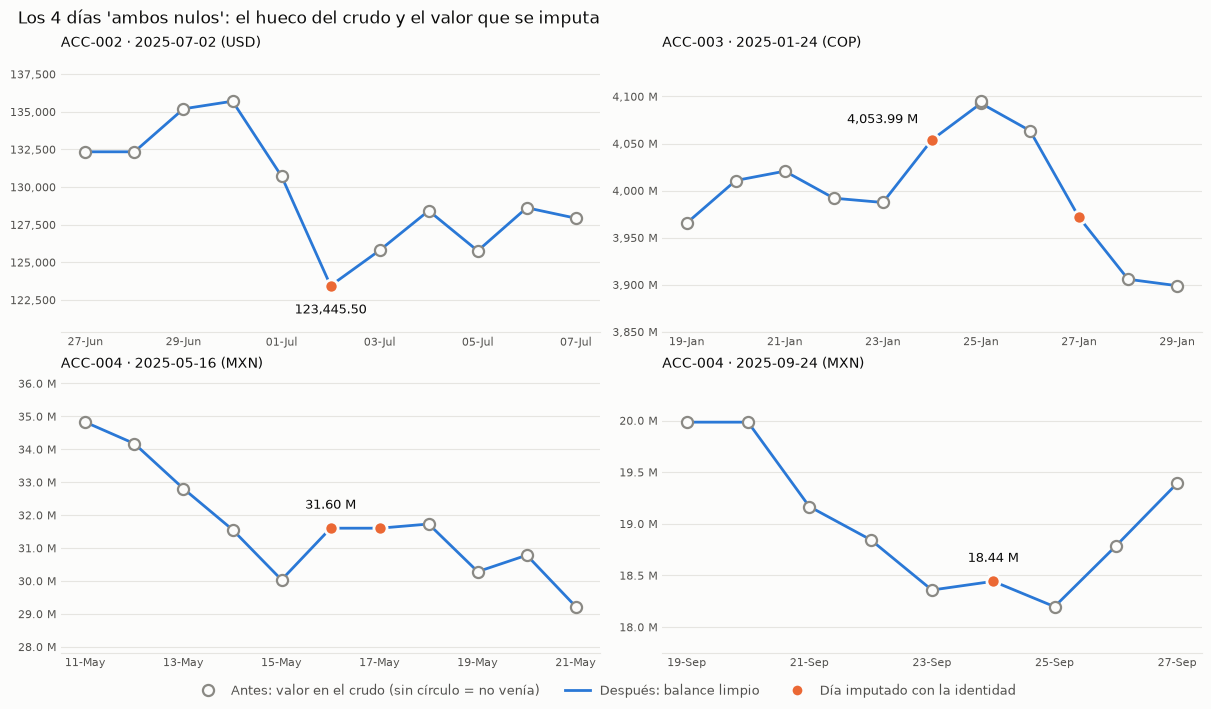

In [21]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# tinta y series (paleta de referencia, modo claro): crudo = neutro, después = serie 1, imputado = serie 2
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
C_BEFORE, C_AFTER, C_IMPUTED = "#8a8984", "#2a78d6", "#eb6834"


def _fmt_axis(vmax, span):
    if vmax < 1e7:
        return FuncFormatter(lambda v, _: f"{v:,.0f}")
    dec = 0 if span >= 5e7 else 1              # rango corto -> 1 decimal, si no las etiquetas se repiten
    return FuncFormatter(lambda v, _: f"{v/1e6:,.{dec}f} M")


def graficar_antes_despues(ax, acc, day, w=5):
    day = pd.Timestamp(day)
    g = ledger[ledger["account_id"] == acc].set_index("date")
    win = g.loc[day - pd.Timedelta(days=w): day + pd.Timedelta(days=w)]
    imputed = win["balance_status"].str.startswith("imputed")

    ax.plot(win.index, win["balance_clean"], color=C_AFTER, lw=2, zorder=2)                       # después
    for col in ("cand_1", "cand_2"):                                                              # antes: cada valor del crudo
        ax.scatter(win.index, win[col], s=64, facecolors=SURFACE, edgecolors=C_BEFORE, linewidths=1.6, zorder=3)
    ax.scatter(win.index[imputed], win.loc[imputed, "balance_clean"], s=90, color=C_IMPUTED,       # imputados
               edgecolors=SURFACE, linewidths=2, zorder=4)

    y = win.loc[day, "balance_clean"]                                                             # etiqueta solo el día foco
    txt = f"{y/1e6:,.2f} M" if abs(y) >= 1e7 else f"{y:,.2f}"
    prev_y, next_y = g["balance_clean"].shift(1).loc[day], g["balance_clean"].shift(-1).loc[day]
    if y < min(prev_y, next_y):                                    # mínimo local: debajo
        off, ha = (0, -20), "center"
    elif y >= max(prev_y, next_y):                                 # máximo local: arriba
        off, ha = (0, 14), "center"
    elif next_y > y:                                               # la línea sube hacia la derecha: etiqueta arriba-izquierda
        off, ha = (-10, 12), "right"
    else:                                                          # baja hacia la derecha: arriba-derecha
        off, ha = (10, 12), "left"
    ax.annotate(txt, (day, y), xytext=off, textcoords="offset points", ha=ha, fontsize=9, color=INK)

    ccy = accounts.set_index("account_id").loc[acc, "currency"]
    ax.set_title(f"{acc} · {day.date()} ({ccy})", fontsize=10, color=INK, loc="left")
    ax.yaxis.set_major_formatter(_fmt_axis(win["balance_clean"].max(), win["balance_clean"].max() - win["balance_clean"].min()))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    ax.margins(y=0.25)
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_2, labelsize=8, length=0)


fig, axes = plt.subplots(2, 2, figsize=(12, 7), facecolor=SURFACE, constrained_layout=True)
for ax, (acc, day) in zip(axes.ravel(), both_null):
    graficar_antes_despues(ax, acc, day)

handles = [
    plt.Line2D([], [], marker="o", ls="", ms=8, mfc=SURFACE, mec=C_BEFORE, mew=1.6, label="Antes: valor en el crudo (sin círculo = no venía)"),
    plt.Line2D([], [], color=C_AFTER, lw=2, label="Después: balance limpio"),
    plt.Line2D([], [], marker="o", ls="", ms=9, color=C_IMPUTED, mec=SURFACE, mew=2, label="Día imputado con la identidad"),
]
fig.legend(handles=handles, loc="outside lower center", ncol=3, frameon=False, fontsize=9, labelcolor=INK_2)
fig.suptitle("Los 4 días 'ambos nulos': el hueco del crudo y el valor que se imputa", fontsize=12, color=INK, x=0.01, ha="left")
plt.show()

**Cómo leerlo.** Donde hay círculo gris **sobre** la línea azul, el crudo y el ledger coinciden (sin cambio). Donde **no hay círculo gris** pero sí punto naranja, el crudo no traía balance y se imputó. En ACC-004 (16-may) hay dos naranjas seguidos: el 17-may también venía vacío (con inflow nulo), así que se imputó hacia atrás.

En ACC-003 el 25-ene hay dos círculos grises casi superpuestos: son las dos filas duplicadas (P3), que difieren apenas 0,05% y a esta escala no se separan; la tabla de arriba sí muestra ambos valores.

El punto naranja del 27-ene en ACC-003 no es un par duplicado: es otro nulo suelto de P4 (una sola fila sin balance) que cae dentro de la ventana.

### 4.9 · Cuadre con el `quality_report`

`quality_report` cuenta P3 con `n_rows == 2` (par duplicado) y `n_candidates == 2` (dos balances no nulos). Verificación cruzada contra el conteo independiente de arriba:

In [22]:
dups = ledger[ledger["n_rows"] == 2]
report_conflicting = int((dups["n_candidates"] == 2).sum())
report_exact = int((dups["n_candidates"] != 2).sum())

assert report_conflicting == int((summary["tipo"] == "balance distinto").sum()) == 44
assert report_exact == int((summary["tipo"] == "ambos nulos").sum()) == 4
print(f"P3 con balance distinto: {report_conflicting}   |   duplicados exactos / ambos nulos: {report_exact}   |   total: {report_conflicting + report_exact}  (= filas sobrantes)")

P3 con balance distinto: 44   |   duplicados exactos / ambos nulos: 4   |   total: 48  (= filas sobrantes)


**Resumen de P3**

1. *Se ve* porque 1.668 − 1.620 = 48 filas sobrantes.
2. *Se detecta* agrupando por (cuenta, fecha parseada); 4 pares son copias exactas con balance nulo, 44 difieren solo en el balance.
3. *Se resuelve* con la identidad: exactamente un candidato deja residuo ≈ 0 en los 44 casos.
4. *Se conserva* esa fila (`observed_reconciled`); un `keep='first'` habría errado en 18 de 44 (41%).

---
## 5 · P4 — Nulos en balance / inflow / outflow

`reconcile_ledger` (ya ejecutado en 4.5) aplica las reglas de reconciliación a cada cuenta.
Un balance nulo se rellena con la identidad; un flujo nulo se recupera si los dos balances vecinos son confiables.

In [23]:
nulls = raw[["balance", "inflow", "outflow"]].isna().sum().rename("nulos en el crudo").to_frame()
nulls["tratamiento"] = ["reconstruidos por identidad", "recuperados por identidad o imputados", "recuperados por identidad o imputados"]
nulls

,nulos en el crudo,tratamiento
balance,68,reconstruidos por identidad
inflow,65,recuperados por identidad o imputados
outflow,65,recuperados por identidad o imputados


In [24]:
print("Estado del balance por día-cuenta (ledger):")
print(ledger["balance_status"].value_counts().to_string())
print("\nEstado de los flujos recuperados en el ledger:")
print(ledger["flow_status"].replace("", "observed").value_counts().to_string())

# los 68 nulos en filas crudas = 64 días-cuenta sin candidato (los 4 pares "ambos nulos" aportan 8 filas para 4 días)
no_cand = ledger["n_candidates"] == 0
print(f"\ndías-cuenta sin ningún balance reportado: {int(no_cand.sum())} → estado: {ledger.loc[no_cand, 'balance_status'].unique().tolist()}")

Estado del balance por día-cuenta (ledger):
balance_status
observed_reconciled           1520
imputed_forward                 58
unreconciled_episode            18
observed_unverified             11
imputed_backward                 6
repaired_sign_flip               4
repaired_decimal_shift_x10       3

Estado de los flujos recuperados en el ledger:
flow_status
observed             1502
inflow_recovered       60
outflow_recovered      58

días-cuenta sin ningún balance reportado: 64 → estado: ['imputed_forward', 'imputed_backward']


---
## 6 · P5 — Lecturas corruptas: signo invertido y decimal corrido

Un balance que no cuadra con la identidad **solo se repara si tiene una firma exacta**: `−1×` (signo invertido) o `10×` (decimal corrido) del valor esperado, con tolerancia relativa `SIGNATURE_RTOL`. Cualquier otra discrepancia no se toca (va a P6).

In [25]:
print("balances negativos en el crudo:", int((raw["balance"] < 0).sum()))

rep = ledger[ledger["balance_status"].str.startswith("repaired")].copy()
rep["razón observado / esperado"] = rep["cand_1"] / rep["balance_clean"]
rep[["account_id", "date", "balance_status", "cand_1", "balance_clean", "razón observado / esperado"]].rename(
    columns={"cand_1": "lectura cruda", "balance_clean": "valor reparado"}
)

balances negativos en el crudo: 4


,account_id,date,balance_status,lectura cruda,valor reparado,razón observado / esperado
198,ACC-001,2025-07-18,repaired_sign_flip,"-2,615,645,702.74","2,615,645,702.74",-1.00
632,ACC-003,2025-04-03,repaired_sign_flip,"-4,070,745,652.07","4,070,745,652.07",-1.00
714,ACC-003,2025-06-24,repaired_sign_flip,"-2,890,859,520.02","2,890,859,520.01",-1.00
1052,ACC-004,2025-08-31,repaired_decimal_shift_x10,"201,223,848.30","20,122,384.83",10.00
1179,ACC-005,2025-04-10,repaired_sign_flip,"-161,888,673.61","161,888,673.61",-1.00
1195,ACC-005,2025-04-26,repaired_decimal_shift_x10,"1,569,232,059.50","156,923,205.96",10.00
1472,ACC-006,2025-05-03,repaired_decimal_shift_x10,"1,518,428.50","151,842.85",10.00


La razón observado/esperado es −1,000 o 10,000 en los 7 casos: por eso son reparaciones exactas y no una adivinanza.

---
## 7 · P6 — Episodios sin explicación: cuarentena

Cuando hay una lectura pero no cuadra con la identidad **ni tiene firma reconocible**, no se inventa una explicación:

- si es **plausible** (dentro de ±`PLAUSIBLE_REL_CHANGE` del vecino confiable pero no verificable) → se acepta con marca `observed_unverified`;
- si no → `unreconciled_episode`: en `build_panel` se sustituye por un **puente lineal** entre el último y el primer saldo confiable, y se marca.

In [26]:
q = ledger[ledger["balance_status"] == "unreconciled_episode"].sort_values(["account_id", "date"]).copy()
q["run"] = (q.groupby("account_id")["date"].diff() != pd.Timedelta(days=1)).cumsum()
episodes = q.groupby("run").agg(account_id=("account_id", "first"), inicio=("date", "min"), fin=("date", "max"), días=("date", "size"))
print(f"días-cuenta en cuarentena: {len(q)}   |   episodios: {len(episodes)}")
episodes

días-cuenta en cuarentena: 18   |   episodios: 6


,account_id,inicio,fin,días
run,,,,
1,ACC-001,2025-03-18,2025-03-20,3
2,ACC-001,2025-08-06,2025-08-08,3
3,ACC-002,2025-03-21,2025-03-23,3
4,ACC-002,2025-08-18,2025-08-20,3
5,ACC-004,2025-05-03,2025-05-05,3
6,ACC-004,2025-09-14,2025-09-16,3


In [27]:
# panel: build_panel aplica el puente lineal; se ve la lectura cruda vs. el valor puenteado
panel = ingest.build_panel(ledger, accounts)
b = panel[panel["balance_status"] == "quarantine_bridged"].merge(
    ledger[["account_id", "date", "cand_1"]], on=["account_id", "date"]
)
b[["account_id", "date", "cand_1", "balance", "balance_status", "flow_status"]].rename(
    columns={"cand_1": "lectura cruda", "balance": "balance puenteado"}
).head(8)

,account_id,date,lectura cruda,balance puenteado,balance_status,flow_status
0,ACC-001,2025-03-18,"695,341,079.66","2,570,401,103.73",quarantine_bridged,bridged_quarantine
1,ACC-001,2025-03-19,"662,282,609.70","2,521,686,312.27",quarantine_bridged,bridged_quarantine
2,ACC-001,2025-03-20,"646,843,726.03","2,472,971,520.82",quarantine_bridged,bridged_quarantine
3,ACC-001,2025-08-06,"832,981,694.25","2,374,417,233.18",quarantine_bridged,bridged_quarantine
4,ACC-001,2025-08-07,"842,474,607.13","2,376,610,858.90",quarantine_bridged,bridged_quarantine
5,ACC-001,2025-08-08,"817,997,060.98","2,378,804,484.62",quarantine_bridged,bridged_quarantine
6,ACC-002,2025-03-21,"42,791.71","189,773.40",quarantine_bridged,bridged_quarantine
7,ACC-002,2025-03-22,"43,919.72","191,480.01",quarantine_bridged,bridged_quarantine


In [28]:
unv = ledger[ledger["balance_status"] == "observed_unverified"]
print(f"lecturas plausibles pero no verificables (aceptadas con marca): {len(unv)}")
unv[["account_id", "date", "balance_clean", "balance_status"]].head(11)

lecturas plausibles pero no verificables (aceptadas con marca): 11


,account_id,date,balance_clean,balance_status
220,ACC-001,2025-08-09,"2,380,998,110.34",observed_unverified
297,ACC-002,2025-01-28,"168,567.90",observed_unverified
456,ACC-002,2025-07-06,"128,625.00",observed_unverified
457,ACC-002,2025-07-07,"127,930.16",observed_unverified
583,ACC-003,2025-02-13,"3,939,685,950.38",observed_unverified
724,ACC-003,2025-07-04,"2,755,900,157.18",observed_unverified
726,ACC-003,2025-07-06,"2,736,406,411.42",observed_unverified
940,ACC-004,2025-05-11,"34,825,178.72",observed_unverified
1080,ACC-005,2025-01-01,"150,333,622.32",observed_unverified
1209,ACC-005,2025-05-10,"145,448,768.10",observed_unverified


---
## 8 · P7 — Identidad contable del panel final y contrato de aceptación

`validate_panel` es la puerta de calidad: **falla** con `AssertionError` si el panel no cumple el contrato
(filas, cero nulos, sin balances negativos, sin huecos de calendario, identidad rota).

In [29]:
# transferencias se limpian aparte (sección 9); aquí solo se agregan como columnas memo antes de validar
transfers_raw = ingest.load_raw_transfers()
transfers, transfers_excluded = ingest.clean_transfers(transfers_raw, accounts)
panel = ingest.transfer_memo_columns(panel, transfers)

ingest.validate_panel(panel)          # si algo no cumple, lanza AssertionError
print("validate_panel: OK")

audit = quality.identity_audit(panel)
print(f"filas del panel        : {len(panel)}  ({cfg.EXPECTED_ACCOUNTS} cuentas × {cfg.EXPECTED_DAYS} días)")
print(f"nulos                  : {int(panel.isna().sum().sum())}")
print(f"residuo máx. identidad : {audit['residual'].abs().max():.6f}   (tolerancia {cfg.RECONCILIATION_TOL})")
print(f"días con residuo > tolerancia: {int((audit['residual'].abs() > cfg.RECONCILIATION_TOL).sum())}")

validate_panel: OK
filas del panel        : 1620  (6 cuentas × 270 días)
nulos                  : 0
residuo máx. identidad : 0.010001   (tolerancia 1.0)
días con residuo > tolerancia: 0


In [30]:
# ¿cuánto del panel es 100% observado/exacto? (columna `reliable`)
print(f"filas confiables: {panel['reliable'].mean():.2%}")
panel.groupby("account_id")["reliable"].mean().map("{:.2%}".format).to_frame("confiables")

filas confiables: 97.65%


,confiables
account_id,
ACC-001,96.30%
ACC-002,95.56%
ACC-003,98.52%
ACC-004,96.67%
ACC-005,98.89%
ACC-006,100.00%


---
## 9 · Transferencias: duplicados exactos

`clean_transfers` valida el log (ids únicos, moneda origen coherente, sin auto-transferencias, lag/fee/monto en rango) y separa los duplicados **exactos** (mismo todo salvo el `transfer_id`). Los excluidos se reportan, no se pierden.

In [31]:
print(f"transferencias crudas: {len(transfers_raw)}  |  limpias: {len(transfers)}  |  excluidas: {len(transfers_excluded)}")

key = [c for c in transfers_raw.columns if c != "transfer_id"]
twins = transfers_excluded[["transfer_id"] + key].merge(
    transfers[["transfer_id"] + key], on=key, suffixes=("_excluida", "_conservada")
)
twins[["transfer_id_excluida", "transfer_id_conservada", "from_account", "to_account", "amount", "date_requested"]]

transferencias crudas: 145  |  limpias: 140  |  excluidas: 5


,transfer_id_excluida,transfer_id_conservada,from_account,to_account,amount,date_requested
0,TRF-0145,TRF-0085,ACC-005,ACC-006,"11,347.91",2025-01-19
1,TRF-0141,TRF-0008,ACC-004,ACC-003,"107,039.18",2025-01-24
2,TRF-0142,TRF-0099,ACC-002,ACC-005,"79,158.77",2025-08-15
3,TRF-0144,TRF-0046,ACC-006,ACC-005,"49,529.82",2025-04-13
4,TRF-0143,TRF-0078,ACC-006,ACC-004,"35,636.25",2025-01-08


---
## 10 · Reporte final de calidad

Misma tabla que produce `quality.quality_report`, con los objetos que armamos paso a paso.

In [32]:
report = quality.quality_report(raw, ledger, panel, transfers_raw, transfers_excluded)
# los conteos llegan como float (P7 es un residuo, no un conteo): se muestran como entero cuando lo son
report["afectados"] = report["afectados"].map(lambda v: f"{v:,.0f}" if float(v).is_integer() else f"{v:.4f}")
report.style.hide(axis="index").set_properties(**{"text-align": "left"})

problema,afectados,tratamiento
Filas entrantes (crudo),"1,668",—
P1 fechas que el parser del squad pierde,293,cascada de 3 formatos: 0 no parseadas
P2 etiquetas de moneda (deben ser 3),9,normalizadas a ISO-4217 y validadas vs accounts.csv
P2 filas con etiqueta no canónica,187,→ moneda de la cuenta
"P3 pares (fecha, cuenta) duplicados con balance distinto",44,se conserva la fila que cuadra con la identidad
P3 pares duplicados exactos/ambos nulos,4,se colapsan; balance por identidad
P4 nulos en balance,68,reconstruidos por identidad
P4 nulos en inflow,65,recuperados por identidad o imputados (marca)
P4 nulos en outflow,65,recuperados por identidad o imputados (marca)
P5 balances negativos en el crudo,4,todos sign-flip exacto (-1x) → reparados


**Cómo leer la tabla.** La columna `afectados` se calcula de los datos; la columna `tratamiento` es texto fijo del módulo (por ejemplo "todos sign-flip exacto" o "≤ 1 unidad en el 100% de los días"). Lo que respalda esas frases son las verificaciones de este notebook y `validate_panel`, no el reporte en sí.